In [13]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('./src')  # ajusta según dónde esté tu notebook respecto a src/

from data_loader import Loader
from data_filter import Filter
from find_peaks_pan_tompkins import Pan_tompkins  # ajusta al nombre real de tu archivo

ecg = Loader('../data/mitdb/100')

Obteniendo record
Obteniendo annotation
Record: <wfdb.io.record.Record object at 0x0000025C980146E0>  Annotation: <wfdb.io.annotation.Annotation object at 0x0000025C98014830>


Obteniendo record
Obteniendo annotation
Record: <wfdb.io.record.Record object at 0x0000025C97FA56D0>  Annotation: <wfdb.io.annotation.Annotation object at 0x0000025C97FA51D0>
Record: <wfdb.io.record.Record object at 0x0000025C97FA56D0>  Annotation: <wfdb.io.annotation.Annotation object at 0x0000025C97FA51D0>


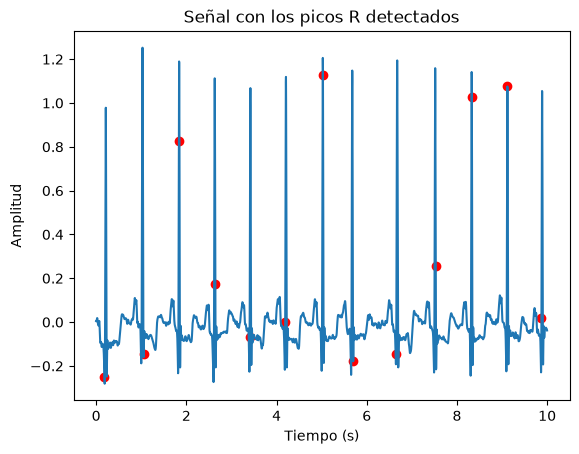

Total de picos detectados: 13


In [ ]:
pt = Pan_tompkins(ecg.record_path) #Aquí creamos un objeto de tipo pan-tompkins, para hallar los picos R
picos, time, seg, convolv = pt.find_peaks(ecg.record) #Encontramos los picos R y los graficamos

print(f"Total de picos detectados: {len(picos)}")

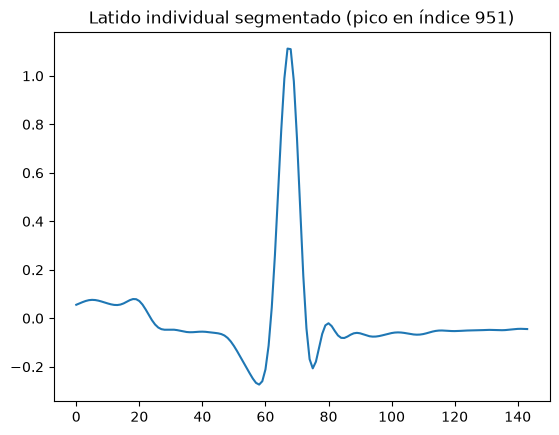

In [15]:
ventana_muestras = int(0.2 * ecg.record.fs)  # ±200ms

pico_prueba = picos[3]  # cualquiera, ni el primero ni el último, para evitar casos de borde
inicio = max(0, pico_prueba - ventana_muestras)
fin = min(len(seg), pico_prueba + ventana_muestras)
latido_prueba = seg[inicio:fin]

plt.plot(latido_prueba)
plt.title(f'Latido individual segmentado (pico en índice {pico_prueba})')
plt.show()

In [16]:
rr = np.zeros(len(picos))
for i in range(1, len(picos)):
    rr[i] = (picos[i] - picos[i-1]) / ecg.record.fs
rr[0] = rr[1]

print(rr)

[0.86666667 0.86666667 0.78333333 0.80833333 0.76111111 0.78888889
 0.83055556 0.67777778 0.93888889 0.88888889 0.79444444 0.79444444
 0.75555556]


In [17]:
pico_prueba = picos[3]
distancias = np.abs(ecg.annotation.sample - pico_prueba)
idx_mas_cercano = np.argmin(distancias)
distancia_minima = distancias[idx_mas_cercano]

print(f"Pico: {pico_prueba}, más cercano real: {ecg.annotation.sample[idx_mas_cercano]}, distancia: {distancia_minima}, símbolo: {ecg.annotation.symbol[idx_mas_cercano]}")

Pico: 951, más cercano real: 946, distancia: 5, símbolo: N
